In [1]:
# ============================================================
# RESTAURANT ORDERS DATA ANALYSIS
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
df = pd.read_csv("restaurant_orders.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
#VIEW THE DATA
print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

#UNDERSTAND THE DATA
print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

# CHECK MISSING VALUES
print("\nMissing values:")
print(df.isnull().sum())



First 5 rows:
   Order ID     Customer Name Food Item Category  Quantity  Price  \
0      2268     Mary Vega DDS     Pasta     Main         5  16.52   
1      3082     Brandon Myers   Brownie  Dessert         4  17.27   
2      3160    Margaret Wells     Pasta     Main         1   3.37   
3      1272  Michael Matthews     Pasta     Main         5   2.20   
4      9447   Connor Williams      Soup  Starter         1  12.23   

   Payment Method           Order Time  
0            Cash  2025-02-02 14:28:41  
1      Debit Card  2025-06-08 10:57:47  
2     Credit Card  2025-03-04 07:41:41  
3  Online Payment  2025-05-15 12:43:45  
4            Cash  2025-03-15 14:25:56  

Last 5 rows:
     Order ID   Customer Name  Food Item Category  Quantity  Price  \
495      6323  Alyssa Anthony      Pizza     Main         1  21.31   
496      9836    Jerry Pineda       Soup  Starter         3  15.99   
497      1202    Brandy Smith      Pasta     Main         2   8.54   
498      7876     Ivan Haynes 

In [5]:
#CHECK DUPLICATE VALUES
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

#BASIC DATA CLEANING
# Remove duplicate rows if there are any
df = df.drop_duplicates()

# Remove extra spaces from text columns
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

print("\nData cleaning completed!")

print("\nNew dataset shape:")
print(df.shape)

#BASIC STATISTICS
print("\nBasic statistics:")
print(df.describe())


Number of duplicate rows:
0

Data cleaning completed!

New dataset shape:
(500, 8)

Basic statistics:
          Order ID    Quantity       Price
count   500.000000  500.000000  500.000000
mean   5683.296000    3.030000   13.197180
std    2599.688068    1.474261    6.685852
min    1055.000000    1.000000    2.060000
25%    3342.000000    2.000000    7.280000
50%    5762.000000    3.000000   13.305000
75%    7945.000000    4.000000   19.080000
max    9997.000000    5.000000   24.990000


In [6]:
#CREATE A NEW COLUMN - TOTAL SALES
df["Total_Sales"] = df["Quantity"] * df["Price"]
print("\nFirst 5 rows with Total Sales:")
print(df.head())


First 5 rows with Total Sales:
   Order ID     Customer Name Food Item Category  Quantity  Price  \
0      2268     Mary Vega DDS     Pasta     Main         5  16.52   
1      3082     Brandon Myers   Brownie  Dessert         4  17.27   
2      3160    Margaret Wells     Pasta     Main         1   3.37   
3      1272  Michael Matthews     Pasta     Main         5   2.20   
4      9447   Connor Williams      Soup  Starter         1  12.23   

   Payment Method           Order Time  Total_Sales  
0            Cash  2025-02-02 14:28:41        82.60  
1      Debit Card  2025-06-08 10:57:47        69.08  
2     Credit Card  2025-03-04 07:41:41         3.37  
3  Online Payment  2025-05-15 12:43:45        11.00  
4            Cash  2025-03-15 14:25:56        12.23  



Q1. Total number of orders: 500

Q2. Food items ordered:
Food Item
Pizza        68
Brownie      63
Fries        60
Salad        55
Cake         53
Ice Cream    52
Burger       51
Soup         50
Pasta        48
Name: count, dtype: int64

Most ordered food item:
Pizza


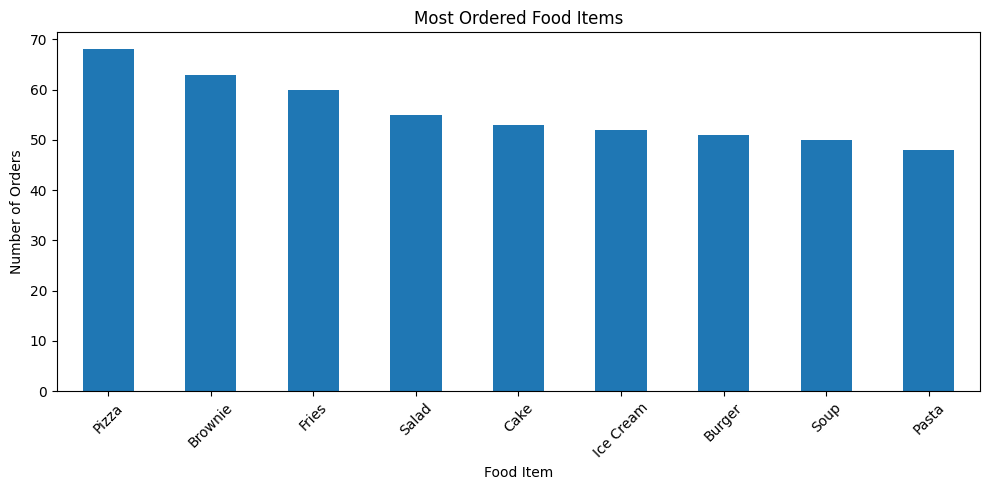

In [10]:
# ============================================================
# QUESTION 1:
# How many total orders are there?
# ============================================================

total_orders = df["Order ID"].nunique()

print("\nQ1. Total number of orders:", total_orders)


# ============================================================
# QUESTION 2:
# Which food item is ordered the most?
# ============================================================

most_ordered_food = df["Food Item"].value_counts()

print("\nQ2. Food items ordered:")
print(most_ordered_food)

print("\nMost ordered food item:")
print(most_ordered_food.idxmax())


# ============================================================
# VISUALIZATION 1:
# Most Ordered Food Items
plt.figure(figsize=(10, 5))

df["Food Item"].value_counts().plot(kind="bar")

plt.title("Most Ordered Food Items")
plt.xlabel("Food Item")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# ============================================================


Q3. Orders by category:
Category
Dessert    168
Main       167
Starter    165
Name: count, dtype: int64

Most popular category:
Dessert


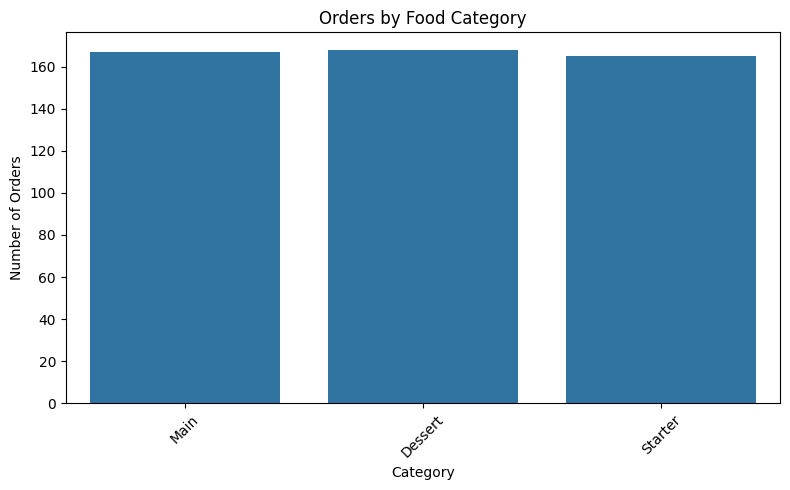

In [11]:
# ============================================================
# QUESTION 3:
# Which category is most popular?
# ============================================================
category_orders = df["Category"].value_counts()

print("\nQ3. Orders by category:")
print(category_orders)

print("\nMost popular category:")
print(category_orders.idxmax())


# ============================================================
# VISUALIZATION 2:
# Orders by Category
# ============================================================
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Category")

plt.title("Orders by Food Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Q4. Average item price: ₹ 13.2

Q5. Total sales by category:
Category
Dessert    6509.99
Main       7026.79
Starter    6486.36
Name: Total_Sales, dtype: float64

Category with highest sales:
Main


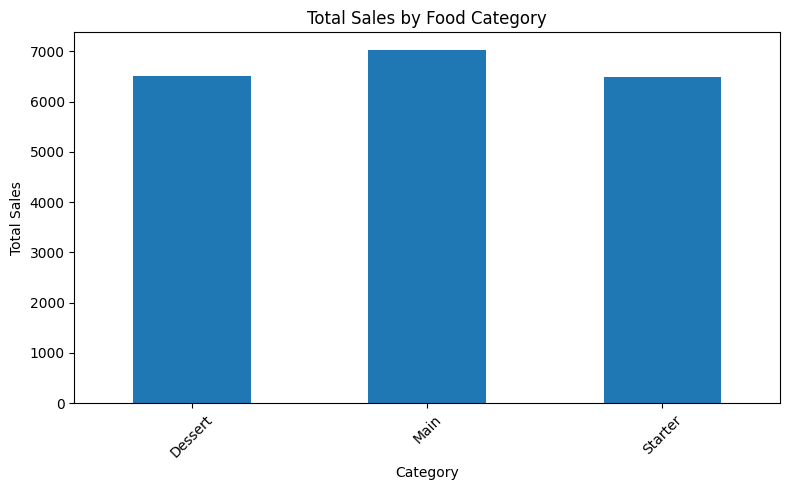

In [12]:
# ============================================================
# QUESTION 4:
# What is the average price of an item?
# ============================================================
average_price = df["Price"].mean()
print("\nQ4. Average item price: ₹", round(average_price, 2))


# ============================================================
# QUESTION 5:
# Which food category generates the highest sales?
# ============================================================
category_sales = df.groupby("Category")["Total_Sales"].sum()

print("\nQ5. Total sales by category:")
print(category_sales)

print("\nCategory with highest sales:")
print(category_sales.idxmax())


# ============================================================
# VISUALIZATION 3:
# Sales by Category
# ============================================================
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Food Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Q6. Payment methods:
Payment Method
Cash              132
Credit Card       128
Online Payment    121
Debit Card        119
Name: count, dtype: int64

Most used payment method:
Cash


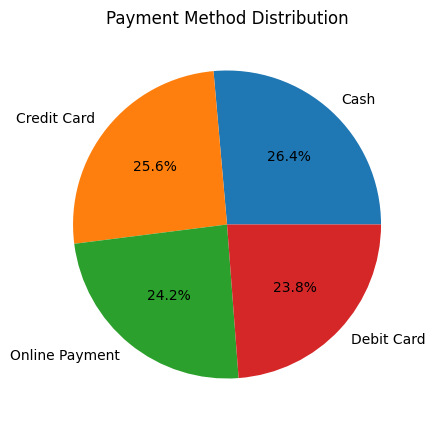

In [14]:
# ============================================================
# QUESTION 6:
# Which payment method is used the most?
# ============================================================
payment_methods = df["Payment Method"].value_counts()

print("\nQ6. Payment methods:")
print(payment_methods)

print("\nMost used payment method:")
print(payment_methods.idxmax())


# ============================================================
# VISUALIZATION 4:
# Payment Method Distribution
# ============================================================
plt.figure(figsize=(7, 5))

payment_methods.plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()



Q7. Sales by food item:
Food Item
Pizza        2627.89
Brownie      2570.19
Fries        2340.48
Pasta        2267.73
Cake         2236.58
Burger       2131.17
Salad        2095.22
Soup         2050.66
Ice Cream    1703.22
Name: Total_Sales, dtype: float64

Food item generating highest sales:
Pizza


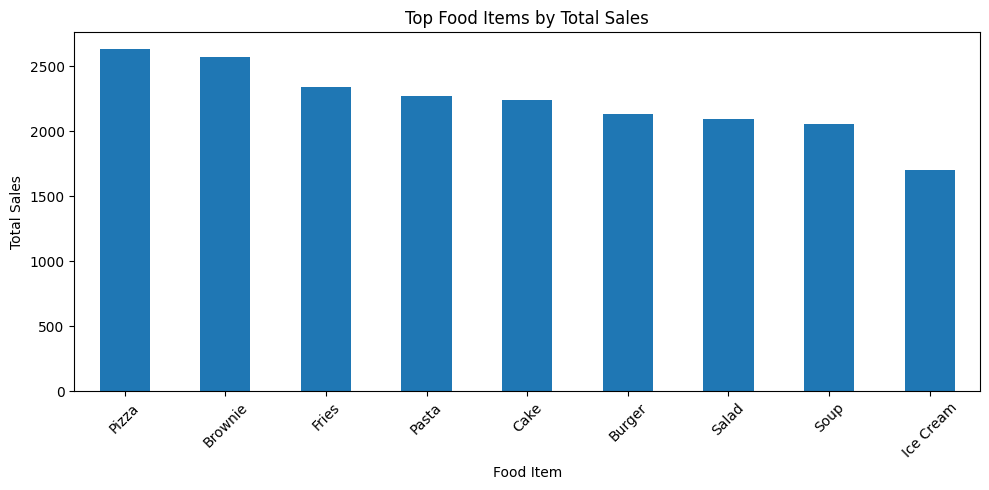

In [16]:
# ============================================================
# QUESTION 7:
# Which food item generates the highest sales?
# ============================================================
food_sales = df.groupby("Food Item")["Total_Sales"].sum()

print("\nQ7. Sales by food item:")
print(food_sales.sort_values(ascending=False))

print("\nFood item generating highest sales:")
print(food_sales.idxmax())


# ============================================================
# VISUALIZATION 5:
# Top Food Items by Sales
# ============================================================
top_food_sales = food_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))

top_food_sales.plot(kind="bar")

plt.title("Top Food Items by Total Sales")
plt.xlabel("Food Item")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Q8. Average quantity ordered: 3.03

Q9. Orders by hour:
Order_Hour
0     21
1     16
2     17
3     20
4     19
5     25
6     16
7     24
8     28
9     23
10    16
11    20
12    30
13    26
14    30
15    17
16    14
17    20
18    22
19    22
20    21
21    17
22    16
23    20
Name: count, dtype: int64

Busiest order hour: 12


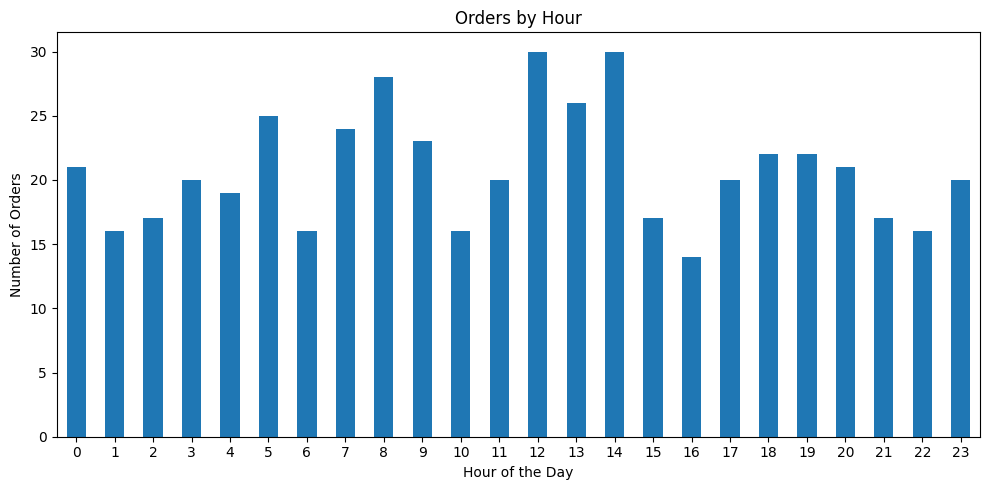

In [18]:
# ============================================================
# QUESTION 8:
# What is the average quantity ordered?
# ============================================================
average_quantity = df["Quantity"].mean()

print("\nQ8. Average quantity ordered:",
      round(average_quantity, 2))


# ============================================================
# QUESTION 9:
# At what time are most orders placed?
# ============================================================
df["Order Time"] = pd.to_datetime(df["Order Time"])

df["Order_Hour"] = df["Order Time"].dt.hour

orders_by_hour = df["Order_Hour"].value_counts().sort_index()

print("\nQ9. Orders by hour:")
print(orders_by_hour)
busiest_hour = orders_by_hour.idxmax()
print("\nBusiest order hour:", busiest_hour)


# ============================================================
# VISUALIZATION 6:
# Orders by Hour
# ============================================================
plt.figure(figsize=(10, 5))

orders_by_hour.plot(kind="bar")

plt.title("Orders by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [19]:
# ============================================================
# STEP 10: TOP 5 FOOD ITEMS
# ============================================================
top_5_foods = df["Food Item"].value_counts().head(5)

print("\nTop 5 most ordered food items:")
print(top_5_foods)


# ============================================================
# STEP 11: OVERALL SALES
# ============================================================
total_sales = df["Total_Sales"].sum()

print("\nTotal Sales: ₹", round(total_sales, 2))


Top 5 most ordered food items:
Food Item
Pizza      68
Brownie    63
Fries      60
Salad      55
Cake       53
Name: count, dtype: int64

Total Sales: ₹ 20023.14


In [20]:
#FINAL SUMMARY VALUES
print("\n" + "="*50)
print("FINAL PROJECT SUMMARY")
print("="*50)

print("Total Orders:", total_orders)

print("Total Sales: ₹", round(total_sales, 2))

print("Average Item Price: ₹", round(average_price, 2))

print("Average Quantity Ordered:",
      round(average_quantity, 2))

print("Most Ordered Food:",
      most_ordered_food.idxmax())

print("Most Popular Category:",
      category_orders.idxmax())

print("Highest Sales Category:",
      category_sales.idxmax())

print("Highest Sales Food Item:",
      food_sales.idxmax())

print("Most Used Payment Method:",
      payment_methods.idxmax())

print("Busiest Order Hour:",
      busiest_hour)

print("="*50)


FINAL PROJECT SUMMARY
Total Orders: 500
Total Sales: ₹ 20023.14
Average Item Price: ₹ 13.2
Average Quantity Ordered: 3.03
Most Ordered Food: Pizza
Most Popular Category: Dessert
Highest Sales Category: Main
Highest Sales Food Item: Pizza
Most Used Payment Method: Cash
Busiest Order Hour: 12
